# A3: Predicting Car Price (Classification)

**GitHub repository**: https://github.com/WinNawee/A3-Predicting_Car_Price  
**Live site**: http://ml.brain.cs.ait.ac.th:8031 (reachable from inside CSIM)

In A1 and A2 we predicted the exact selling price. In this assignment the
same used car dataset is turned into a **4 class classification** problem:
`selling_price` is split into 4 price bands, and a multinomial Logistic
Regression written from scratch predicts which band a car belongs to.

What this notebook covers:

* **Task 1**: put `selling_price` into 4 classes, extend the
  `LogisticRegression` class (softmax + gradient descent), and add
  `accuracy`, `precision`, `recall`, `f1_score`, macro and weighted
  averages to the class. I check my results against
  `sklearn.metrics.classification_report`.
* **Task 2**: add an optional Ridge (L2) penalty to the loss and gradient.
* **Task 3**: log the experiments with MLflow, register the best model in
  Staging, and set up CI/CD for the web app. The course MLflow server was
  down, so following the TA announcement (1 Oct 2026) the runs are logged
  to a local MLflow instance, like in A2. Screenshots of the MLflow UI are included in Sections 5 to 7, and the
  CI/CD and deployment are described in Section 8.

In [1]:
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report as sk_classification_report

np.random.seed(42)
STUDENT_ID = "st127031"

## 1. Load the Car Price dataset

Same raw `Cars.csv` as A1 and A2. Columns: `name, year, selling_price,
km_driven, fuel, seller_type, transmission, owner, mileage, engine,
max_power, torque, seats`.

In [2]:
df = pd.read_csv("data/Cars.csv")
print(df.shape)
df.head()

(8128, 13)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [3]:
df.isna().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

## 2. Preprocessing (same steps as A1/A2)

* `mileage` ("23.4 kmpl"), `engine` ("1248 CC") and `max_power`
  ("74 bhp"): remove the unit and keep the number.
* `torque` is dropped. Its format is very inconsistent and A1/A2 did not
  use it either.
* `brand` is the first word of `name`. Brands with fewer than 20 cars in
  the training set become `"Other"`.
* Only Diesel and Petrol cars are kept. CNG/LPG are about 1% of the data
  and use a different mileage unit (km/kg), and they were removed in
  A1/A2 as well.
* `owner` is encoded as an ordered number (First Owner = 0, ..., Test
  Drive Car = 4).
* Missing values are filled later inside the `ColumnTransformer` (median
  for numbers, most frequent value for categories), fitted on the
  training set only.

In [4]:
def parse_number(s):
    """'23.4 kmpl' -> 23.4, '1248 CC' -> 1248.0, NaN stays NaN"""
    if pd.isna(s):
        return np.nan
    m = re.search(r"[\d.]+", str(s))
    return float(m.group()) if m else np.nan


df = df[df["fuel"].isin(["Diesel", "Petrol"])].reset_index(drop=True)

df["mileage"] = df["mileage"].apply(parse_number)
df["engine"] = df["engine"].apply(parse_number)
df["max_power"] = df["max_power"].apply(parse_number)
df["brand"] = df["name"].apply(lambda x: str(x).split(" ")[0])
df = df.drop(columns=["torque"])

OWNER_SCALE = {
    "First Owner": 0,
    "Second Owner": 1,
    "Third Owner": 2,
    "Fourth & Above Owner": 3,
    "Test Drive Car": 4,
}
df["owner"] = df["owner"].map(OWNER_SCALE)

print(df.shape)
df.isna().sum()

(8033, 13)


name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          214
engine           214
max_power        208
seats            214
brand              0
dtype: int64

### Remove duplicate rows before splitting (data leakage fix 1)

The dataset has many repeated listings. If the same car is in both the
training set and the test set, the model is tested on rows it has already
seen, and the test score looks better than it really is. So duplicates
are removed **before** the split. I compare all the columns the model can
see (features and target), which also catches cars that only differ in
the variant `name`.

In [5]:
MODEL_VISIBLE_COLS = ["year", "km_driven", "mileage", "engine", "max_power", "seats",
                      "owner", "fuel", "transmission", "seller_type", "brand", "selling_price"]

n_before = len(df)
df = df.drop_duplicates(subset=MODEL_VISIBLE_COLS).reset_index(drop=True)
print(f"Dropped {n_before - len(df)} duplicate rows, {len(df)} unique rows remain")

Dropped 1220 duplicate rows, 6813 unique rows remain


### Train / validation / test split (data leakage fix 2)

* **train (64%)**: used to fit everything (brand grouping, class edges,
  imputers, scaler, model weights).
* **validation (16%)**: used to compare models and hyperparameters
  (no penalty vs ridge, the MLflow runs, choosing the best run).
* **test (20%)**: used **only once** at the end, on the model already
  chosen with the validation set. If I picked the best model by its test
  score, the test set would be part of model selection and the final score
  would be too optimistic.

In [6]:
df_trainval, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_trainval, test_size=0.2, random_state=42)
print("train:", df_train.shape, " val:", df_val.shape, " test:", df_test.shape)

# check: no car in the test set should also be in the training set
overlap = df_test.merge(df_train, on=MODEL_VISIBLE_COLS, how="inner")
print("test rows that also appear in train:", len(overlap))

train: (4360, 13)  val: (1090, 13)  test: (1363, 13)


test rows that also appear in train: 0


Group brands into `"Other"`. Only brands with at least 20 cars in the
training set keep their own name. Every other brand becomes `"Other"`,
including brands that never appear in the training set (they may still
show up in validation, test, or in the web app). The list of common
brands is saved with the model so the app does exactly the same thing.

In [7]:
brand_counts = df_train["brand"].value_counts()
COMMON_BRANDS = sorted(brand_counts[brand_counts >= 20].index)


def group_brand(b):
    return b if b in COMMON_BRANDS else "Other"


df_train = df_train.copy()
df_val = df_val.copy()
df_test = df_test.copy()
for _d in (df_train, df_val, df_test):
    _d["brand"] = _d["brand"].apply(group_brand)

NUM_COLS = ["year", "km_driven", "mileage", "engine", "max_power", "seats", "owner"]
TWO_LEVEL_COLS = ["fuel", "transmission"]
MULTI_LEVEL_COLS = ["seller_type", "brand"]
FEATURE_COLS = NUM_COLS + TWO_LEVEL_COLS + MULTI_LEVEL_COLS

### 2.1 Put `selling_price` into 4 classes

I use `pd.qcut` (quantile cut) on the **training set only**, then apply
the same bin edges to the validation and test sets with `pd.cut`. This
gives 4 classes of about the same size.

I did not use an equal width `pd.cut`. A few very expensive cars stretch
the price range so much that more than 90% of the cars would end up in
the first bin.

In [8]:
train_classes, bin_edges = pd.qcut(
    df_train["selling_price"], q=4, labels=[0, 1, 2, 3], retbins=True
)
y_train = train_classes.astype(int).values

# open the outer edges so every price in val/test falls into some bin
bin_edges_open = bin_edges.copy()
bin_edges_open[0] = -np.inf
bin_edges_open[-1] = np.inf


def to_class(prices):
    return pd.cut(prices, bins=bin_edges_open, labels=[0, 1, 2, 3]).astype(int).values


y_val = to_class(df_val["selling_price"])
y_test = to_class(df_test["selling_price"])

CLASS_LABELS = {0: "Budget", 1: "Mid-range", 2: "Premium", 3: "Luxury"}
CLASS_PRICE_RANGES = {
    int(c): f"₹{bin_edges[c]:,.0f} – ₹{bin_edges[c+1]:,.0f}" for c in range(4)
}
for c in range(4):
    print(f"Class {c} ({CLASS_LABELS[c]}): {CLASS_PRICE_RANGES[c]}")

print("\nTrain class balance:", np.bincount(y_train))
print("Val class balance:  ", np.bincount(y_val))
print("Test class balance: ", np.bincount(y_test))

Class 0 (Budget): ₹30,000 – ₹250,000
Class 1 (Mid-range): ₹250,000 – ₹405,000
Class 2 (Premium): ₹405,000 – ₹635,000
Class 3 (Luxury): ₹635,000 – ₹7,200,000

Train class balance: [1170 1011 1093 1086]
Val class balance:   [311 242 261 276]
Test class balance:  [360 289 357 357]


### 2.2 `ColumnTransformer` (same structure as the A1/A2 `prep` pipeline)

* Numeric columns: fill missing with the median, then standardize.
* Two level categories (fuel, transmission): fill with the most frequent
  value, then one hot encode with `drop="if_binary"`.
* Multi level categories (seller_type, brand): fill with the most
  frequent value, then one hot encode. `handle_unknown="ignore"` means a
  brand the model has never seen will not crash the web app.

It is fitted on the **training set only**.

In [9]:
prep = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("fillna", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]), NUM_COLS),
        ("two", Pipeline([
            ("fillna", SimpleImputer(strategy="most_frequent")),
            ("encode", OneHotEncoder(drop="if_binary", handle_unknown="ignore")),
        ]), TWO_LEVEL_COLS),
        ("multi", Pipeline([
            ("fillna", SimpleImputer(strategy="most_frequent")),
            ("encode", OneHotEncoder(handle_unknown="ignore")),
        ]), MULTI_LEVEL_COLS),
    ],
    remainder="drop",
)


def add_intercept(X):
    return np.concatenate([np.ones((X.shape[0], 1)), X], axis=1)


def to_dense(X):
    return X.toarray() if hasattr(X, "toarray") else X


# fit on train ONLY, validation and test are only transformed
X_train = add_intercept(to_dense(prep.fit_transform(df_train[FEATURE_COLS])))
X_val = add_intercept(to_dense(prep.transform(df_val[FEATURE_COLS])))
X_test = add_intercept(to_dense(prep.transform(df_test[FEATURE_COLS])))

k = 4                   # number of classes
n = X_train.shape[1]    # number of features, including the intercept
m = X_train.shape[0]    # number of training samples

# Y must be one hot with shape (m, k) for softmax regression
Y_train_onehot = np.zeros((m, k))
for c in range(k):
    Y_train_onehot[y_train == c, c] = 1

print("X_train:", X_train.shape, " X_val:", X_val.shape, " X_test:", X_test.shape,
      " n features (incl. intercept):", n)

X_train: (4360, 30)  X_val: (1090, 30)  X_test: (1363, 30)  n features (incl. intercept): 30


## 3. Task 1: Multinomial Logistic Regression and metrics from scratch

### 3.1 The `LogisticRegression` class

The base is the class from `02 - Multinomial Logistic Regression.ipynb`
(softmax output, cross entropy loss, batch / minibatch / stochastic
gradient descent). My changes:

1. **Classification metrics are now methods of the class** (Task 1):
   `accuracy`, `precision`, `recall`, `f1_score`, `macro_precision`,
   `macro_recall`, `macro_f1`, `weighted_precision`, `weighted_recall`,
   `weighted_f1`, plus `classification_report` to print them like
   sklearn. They are class methods, so they work on a trained model
   (`model.accuracy(y, yhat)`) and also without one
   (`LogisticRegression.accuracy(y, yhat)`), which I need for the mock
   data check.
2. **`use_penalty` and `l`**: optional Ridge (L2) penalty (Task 2).
3. **The gradient is divided by the batch size `m`.** The original class
   uses `grad = X.T @ error` without `1/m`. That was fine for the small
   iris example (about 100 rows), but our training set has 4,360 rows,
   so the gradient became very large and needed a tiny `alpha` to not
   diverge. After dividing by `m` the step size does not depend on the
   batch size, so the same `alpha` works for batch and minibatch.
4. **Softmax subtracts the row maximum** before `exp()` to avoid overflow.
   The probabilities do not change.

In [10]:
class RidgePenalty:
    """L2 penalty on the weight matrix W (n_features, n_classes).
    Row 0 of W is the bias, which is not penalized."""

    def __init__(self, l=0.0):
        self.l = l

    def __call__(self, W):
        return self.l * np.sum(np.square(W[1:, :]))

    def derivation(self, W):
        # derivative of l * sum(W^2) is 2 * l * W
        grad = self.l * 2 * W
        grad[0, :] = 0.0
        return grad


class NoPenalty:
    """Used when use_penalty=False, adds nothing to the loss or gradient."""

    def __call__(self, W):
        return 0.0

    def derivation(self, W):
        return np.zeros_like(W)


class LogisticRegression:

    def __init__(self, k, n, method="batch", alpha=0.001, max_iter=5000,
                 use_penalty=False, l=0.1, verbose=False, random_state=None):
        self.k, self.n, self.method = k, n, method
        self.alpha, self.max_iter, self.verbose = alpha, max_iter, verbose
        self.use_penalty, self.l = use_penalty, l
        self.random_state = random_state
        self.regularization = RidgePenalty(l) if use_penalty else NoPenalty()

    # ------------------------------------------------------------------
    # training
    # ------------------------------------------------------------------
    def fit(self, X, Y):
        rng = np.random.RandomState(self.random_state)
        self.W = rng.rand(self.n, self.k)
        self.losses = []
        m_total = X.shape[0]
        self.m_total = m_total   # used to scale the ridge term (see gradient)

        if self.method == "batch":
            start = time.time()
            for i in range(self.max_iter):
                loss, grad = self.gradient(X, Y)
                self.losses.append(loss)
                self.W = self.W - self.alpha * grad
                if self.verbose and i % 1000 == 0:
                    print(f"iter {i}: loss={loss:.4f}")
            if self.verbose:
                print(f"time taken: {time.time()-start:.2f}s")

        elif self.method == "minibatch":
            start = time.time()
            batch_size = max(1, int(0.3 * m_total))
            for i in range(self.max_iter):
                ix = rng.randint(0, m_total)
                batch_X, batch_Y = X[ix:ix + batch_size], Y[ix:ix + batch_size]
                if batch_X.shape[0] == 0:
                    continue
                loss, grad = self.gradient(batch_X, batch_Y)
                self.losses.append(loss)
                self.W = self.W - self.alpha * grad
                if self.verbose and i % 1000 == 0:
                    print(f"iter {i}: loss={loss:.4f}")
            if self.verbose:
                print(f"time taken: {time.time()-start:.2f}s")

        elif self.method == "sto":
            start = time.time()
            used = []
            for i in range(self.max_iter):
                idx = rng.randint(m_total)
                while idx in used:
                    idx = rng.randint(m_total)
                X_i, Y_i = X[idx, :].reshape(1, -1), Y[idx].reshape(1, -1)
                loss, grad = self.gradient(X_i, Y_i)
                self.losses.append(loss)
                self.W = self.W - self.alpha * grad
                used.append(idx)
                if len(used) == m_total:
                    used = []
                if self.verbose and i % 1000 == 0:
                    print(f"iter {i}: loss={loss:.4f}")
            if self.verbose:
                print(f"time taken: {time.time()-start:.2f}s")
        else:
            raise ValueError('method must be one of "batch", "minibatch" or "sto".')
        return self

    def gradient(self, X, Y):
        m = X.shape[0]                      # size of this batch
        N = getattr(self, "m_total", m)     # size of the whole training set
        h = self.h_theta(X, self.W)
        # cross entropy is averaged over the batch. The ridge term is divided
        # by the full training size N, so its strength does not change with
        # the batch size (for "batch" N == m, for "sto" m == 1).
        ce_loss = -np.sum(Y * np.log(h + 1e-15)) / m
        penalty_loss = self.regularization(self.W) / N
        loss = ce_loss + penalty_loss

        error = h - Y
        grad = (X.T @ error) / m + self.regularization.derivation(self.W) / N
        return loss, grad

    def softmax(self, z):
        z = z - np.max(z, axis=1, keepdims=True)
        e = np.exp(z)
        return e / np.sum(e, axis=1, keepdims=True)

    def h_theta(self, X, W):
        return self.softmax(X @ W)

    def predict(self, X):
        return np.argmax(self.h_theta(X, self.W), axis=1)

    def predict_proba(self, X):
        return self.h_theta(X, self.W)

    # ------------------------------------------------------------------
    # Task 1: classification metrics, written from scratch
    # (no sklearn.metrics used in here)
    # ------------------------------------------------------------------
    @staticmethod
    def _confusion_counts(y_true, y_pred, c):
        """TP, FP, FN for class c (one class vs the rest)."""
        y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
        tp = int(np.sum((y_true == c) & (y_pred == c)))
        fp = int(np.sum((y_true != c) & (y_pred == c)))
        fn = int(np.sum((y_true == c) & (y_pred != c)))
        return tp, fp, fn

    @staticmethod
    def _classes(y_true, y_pred, classes):
        """Classes to report on. Like sklearn, use every label that appears
        in y_true OR y_pred."""
        if classes is not None:
            return classes
        return np.unique(np.concatenate([np.asarray(y_true), np.asarray(y_pred)]))

    @classmethod
    def accuracy(cls, y_true, y_pred):
        """correct predictions / all predictions"""
        y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
        return float(np.sum(y_true == y_pred) / len(y_true))

    @classmethod
    def precision(cls, y_true, y_pred, classes=None):
        """precision_c = TP_c / (TP_c + FP_c), one value per class"""
        out = []
        for c in cls._classes(y_true, y_pred, classes):
            tp, fp, fn = cls._confusion_counts(y_true, y_pred, c)
            out.append(tp / (tp + fp) if (tp + fp) > 0 else 0.0)
        return np.array(out)

    @classmethod
    def recall(cls, y_true, y_pred, classes=None):
        """recall_c = TP_c / (TP_c + FN_c), one value per class"""
        out = []
        for c in cls._classes(y_true, y_pred, classes):
            tp, fp, fn = cls._confusion_counts(y_true, y_pred, c)
            out.append(tp / (tp + fn) if (tp + fn) > 0 else 0.0)
        return np.array(out)

    @classmethod
    def f1_score(cls, y_true, y_pred, classes=None):
        """f1_c = 2 * precision_c * recall_c / (precision_c + recall_c)"""
        p = cls.precision(y_true, y_pred, classes)
        r = cls.recall(y_true, y_pred, classes)
        denom = p + r
        return np.divide(2 * p * r, denom, out=np.zeros_like(denom), where=denom > 0)

    @classmethod
    def support(cls, y_true, classes=None):
        """number of true samples in each class"""
        y_true = np.asarray(y_true)
        if classes is None:
            classes = np.unique(y_true)
        return np.array([int(np.sum(y_true == c)) for c in classes])

    # macro: simple average over the classes
    @classmethod
    def macro_precision(cls, y_true, y_pred, classes=None):
        return float(cls.precision(y_true, y_pred, classes).mean())

    @classmethod
    def macro_recall(cls, y_true, y_pred, classes=None):
        return float(cls.recall(y_true, y_pred, classes).mean())

    @classmethod
    def macro_f1(cls, y_true, y_pred, classes=None):
        return float(cls.f1_score(y_true, y_pred, classes).mean())

    # weighted: each class weighted by its share of the true labels
    @classmethod
    def _weighted(cls, scores, y_true, classes):
        s = cls.support(y_true, classes)
        return float(np.sum(scores * s) / np.sum(s))

    @classmethod
    def weighted_precision(cls, y_true, y_pred, classes=None):
        classes = cls._classes(y_true, y_pred, classes)
        return cls._weighted(cls.precision(y_true, y_pred, classes), y_true, classes)

    @classmethod
    def weighted_recall(cls, y_true, y_pred, classes=None):
        classes = cls._classes(y_true, y_pred, classes)
        return cls._weighted(cls.recall(y_true, y_pred, classes), y_true, classes)

    @classmethod
    def weighted_f1(cls, y_true, y_pred, classes=None):
        classes = cls._classes(y_true, y_pred, classes)
        return cls._weighted(cls.f1_score(y_true, y_pred, classes), y_true, classes)

    @classmethod
    def classification_report(cls, y_true, y_pred, classes=None, digits=2):
        """Same layout as sklearn.metrics.classification_report."""
        classes = cls._classes(y_true, y_pred, classes)
        p, r = cls.precision(y_true, y_pred, classes), cls.recall(y_true, y_pred, classes)
        f1, s = cls.f1_score(y_true, y_pred, classes), cls.support(y_true, classes)

        lines = [f"{'':>12}{'precision':>12}{'recall':>12}{'f1-score':>12}{'support':>12}", ""]
        for i, c in enumerate(classes):
            lines.append(f"{str(c):>12}{p[i]:>12.{digits}f}{r[i]:>12.{digits}f}{f1[i]:>12.{digits}f}{s[i]:>12d}")
        lines.append("")
        acc, total = cls.accuracy(y_true, y_pred), int(np.sum(s))
        lines.append(f"{'accuracy':>12}{'':>12}{'':>12}{acc:>12.{digits}f}{total:>12d}")
        lines.append(f"{'macro avg':>12}{p.mean():>12.{digits}f}{r.mean():>12.{digits}f}{f1.mean():>12.{digits}f}{total:>12d}")
        wp = cls.weighted_precision(y_true, y_pred, classes)
        wr = cls.weighted_recall(y_true, y_pred, classes)
        wf1 = cls.weighted_f1(y_true, y_pred, classes)
        lines.append(f"{'weighted avg':>12}{wp:>12.{digits}f}{wr:>12.{digits}f}{wf1:>12.{digits}f}{total:>12d}")
        return "\n".join(lines)

### 3.2 About the weighted average

Weighted precision multiplies each class's precision by that class's
share of the true labels (its `support` divided by the total) and adds
them up. For example, with 20% / 30% / 20% / 30% of the samples in
classes 0 to 3:

$$\text{weighted precision} = 0.2\,p_0 + 0.3\,p_1 + 0.2\,p_2 + 0.3\,p_3$$

The weights already add up to 1, so I do not divide by 4 again. The
assignment PDF shows the weighted formula with a division by 4, but with
it the result would be 4 times smaller than sklearn's `weighted avg`.
Since the task asks to compare with sklearn, I follow the sklearn
definition, and the numbers below match it exactly.

For the rest of the notebook I make short names for the metric methods
so the code is easier to read:

In [11]:
accuracy = LogisticRegression.accuracy
macro_precision = LogisticRegression.macro_precision
macro_recall = LogisticRegression.macro_recall
macro_f1 = LogisticRegression.macro_f1
weighted_precision = LogisticRegression.weighted_precision
weighted_recall = LogisticRegression.weighted_recall
weighted_f1 = LogisticRegression.weighted_f1
classification_report_scratch = LogisticRegression.classification_report

### 3.3 Compare with `sklearn.metrics.classification_report` (mock data)

I made the mock data **imbalanced on purpose** (50 / 30 / 15 / 5 samples
per class). With balanced classes, macro and weighted averages would be
almost the same, so the check would not really test the weighted part.

In [12]:
rng = np.random.RandomState(0)
mock_y_true = np.array([0] * 50 + [1] * 30 + [2] * 15 + [3] * 5)
rng.shuffle(mock_y_true)
mock_y_pred = mock_y_true.copy()
flip_idx = rng.choice(len(mock_y_pred), size=20, replace=False)
mock_y_pred[flip_idx] = rng.randint(0, 4, size=20)   # make 20 predictions random

print("=" * 26, "FROM SCRATCH", "=" * 26)
print(LogisticRegression.classification_report(mock_y_true, mock_y_pred))
print()
print("=" * 28, "SKLEARN", "=" * 28)
print(sk_classification_report(mock_y_true, mock_y_pred, digits=2))

========================== FROM SCRATCH ==========================
               precision      recall    f1-score     support

           0        0.93        0.84        0.88          50
           1        0.96        0.83        0.89          30
           2        0.74        0.93        0.82          15
           3        0.30        0.60        0.40           5

    accuracy                                0.84         100
   macro avg        0.73        0.80        0.75         100
weighted avg        0.88        0.84        0.85         100

============================ SKLEARN ============================
              precision    recall  f1-score   support

           0       0.93      0.84      0.88        50
           1       0.96      0.83      0.89        30
           2       0.74      0.93      0.82        15
           3       0.30      0.60      0.40         5

    accuracy                           0.84       100
   macro avg       0.73      0.80      0.75       

Every number (per class precision, recall, f1, accuracy, macro avg and
weighted avg) is the same as sklearn's report.

**Q: What does `support` mean in the classification report?**

**A:** It is the number of *true* samples of each class in `y_true`. It
does not depend on the predictions. It shows how many samples each
class's score is based on (a class with support 5 gives a much less
reliable score than one with support 500), and it is the weight used in
the `weighted avg` row.

### 3.4 Train on the Car Price data (no penalty)

The results here are on the **validation** set. The test set is not used
until Section 6.

In [13]:
model_base = LogisticRegression(
    k=k, n=n, method="batch", alpha=1.0, max_iter=5000,
    use_penalty=False, verbose=True, random_state=1,
)
model_base.fit(X_train, Y_train_onehot)

iter 0: loss=1.9131
iter 1000: loss=0.5911
iter 2000: loss=0.5870
iter 3000: loss=0.5859
iter 4000: loss=0.5853
time taken: 2.79s


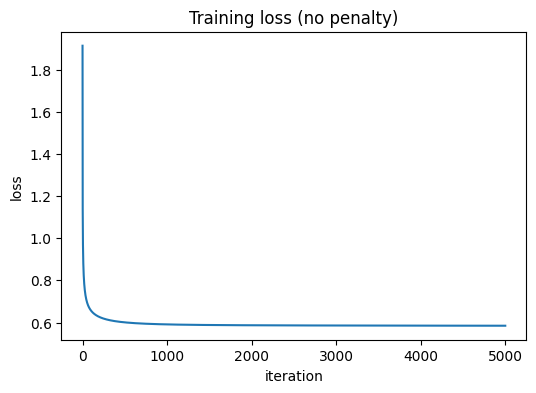

In [14]:
plt.figure(figsize=(6, 4))
plt.plot(model_base.losses)
plt.title("Training loss (no penalty)")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.show()

In [15]:
yhat_base = model_base.predict(X_val)

print("=" * 22, "FROM SCRATCH (validation)", "=" * 22)
print(model_base.classification_report(y_val, yhat_base))   # metric method on the trained model
print()
print("=" * 24, "SKLEARN (validation)", "=" * 24)
print(sk_classification_report(y_val, yhat_base, digits=2))

====================== FROM SCRATCH (validation) ======================
               precision      recall    f1-score     support

           0        0.89        0.80        0.84         311
           1        0.61        0.64        0.62         242
           2        0.62        0.67        0.65         261
           3        0.83        0.83        0.83         276

    accuracy                                0.74        1090
   macro avg        0.74        0.74        0.74        1090
weighted avg        0.75        0.74        0.74        1090

======================== SKLEARN (validation) ========================
              precision    recall  f1-score   support

           0       0.89      0.80      0.84       311
           1       0.61      0.64      0.62       242
           2       0.62      0.67      0.65       261
           3       0.83      0.83      0.83       276

    accuracy                           0.74      1090
   macro avg       0.74      0.74      0

## 4. Task 2: Ridge (L2) penalty

$$ J(\theta) = -\sum_{i=1}^m y^{(i)}\log(h^{(i)}) + \lambda\sum_{j=1}^n \theta_j^2 $$

`RidgePenalty` is adapted from `03 - Bias-Variance Tradeoff and
Regularization.ipynb`. Here theta is a weight **matrix** `W` (features x
classes) instead of a vector, so the penalty is the sum of squares of all
its entries. The bias row is not penalized. It is turned on with
`LogisticRegression(..., use_penalty=True, l=<lambda>)` and off with
`use_penalty=False` (the default).

In [16]:
model_ridge = LogisticRegression(
    k=k, n=n, method="batch", alpha=1.0, max_iter=5000,
    use_penalty=True, l=0.5, verbose=True, random_state=1,
)
model_ridge.fit(X_train, Y_train_onehot)
yhat_ridge = model_ridge.predict(X_val)

iter 0: loss=1.9177
iter 1000: loss=0.6086
iter 2000: loss=0.6057
iter 3000: loss=0.6048
iter 4000: loss=0.6043
time taken: 2.71s


In [17]:
# compared on VALIDATION, not test
comparison = pd.DataFrame({
    "metric": ["accuracy", "macro_precision", "macro_recall", "macro_f1",
               "weighted_precision", "weighted_recall", "weighted_f1"],
    "no_penalty": [accuracy(y_val, yhat_base), macro_precision(y_val, yhat_base),
                   macro_recall(y_val, yhat_base), macro_f1(y_val, yhat_base),
                   weighted_precision(y_val, yhat_base), weighted_recall(y_val, yhat_base),
                   weighted_f1(y_val, yhat_base)],
    "ridge_l2 (l=0.5)": [accuracy(y_val, yhat_ridge), macro_precision(y_val, yhat_ridge),
                         macro_recall(y_val, yhat_ridge), macro_f1(y_val, yhat_ridge),
                         weighted_precision(y_val, yhat_ridge), weighted_recall(y_val, yhat_ridge),
                         weighted_f1(y_val, yhat_ridge)],
})
comparison

,metric,no_penalty,ridge_l2 (l=0.5)
0,accuracy,0.741284,0.744037
1,macro_precision,0.738374,0.739996
2,macro_recall,0.735210,0.737923
3,macro_f1,0.735926,0.738211
4,weighted_precision,0.748781,0.750326
5,weighted_recall,0.741284,0.744037
6,weighted_f1,0.744101,0.746371


The penalty should make the weights smaller. Sum of squared weights
(without the bias row):

In [18]:
print("no penalty    -- sum(W[1:]**2):", round(float(np.sum(model_base.W[1:, :] ** 2)), 3))
print("ridge (l=0.5) -- sum(W[1:]**2):", round(float(np.sum(model_ridge.W[1:, :] ** 2)), 3))

no penalty    -- sum(W[1:]**2): 221.477
ridge (l=0.5) -- sum(W[1:]**2): 138.893


## 5. Task 3.1: Log the experiments with MLflow

Experiment name `<student_ID>-a3`. Params, metrics and the model are
logged, the dataset is not.

**Note:** the course MLflow server (`mlflow.ml.brain.cs.ait.ac.th`) was
down. Following the TA announcement on 1 Oct 2026, logging to it is no
longer required, and screenshots of a local MLflow instance are submitted
instead (see the README). The cell below still tries the course server
first. If it cannot connect, it logs to a local SQLite store
(`mlflow_fallback.db`) like in A2.

In [19]:
import mlflow
import mlflow.pyfunc
from mlflow.tracking import MlflowClient

AIT_MLFLOW_URI = "http://mlflow.ml.brain.cs.ait.ac.th/"
EXPERIMENT_NAME = f"{STUDENT_ID}-a3"

try:
    mlflow.set_tracking_uri(AIT_MLFLOW_URI)
    mlflow.set_experiment(EXPERIMENT_NAME)
    _ = MlflowClient().search_experiments()  # makes a real request to the server
    print(f"Connected to AIT MLflow server, logging to '{EXPERIMENT_NAME}'")
except Exception as e:
    fallback_uri = "sqlite:///mlflow_fallback.db"
    mlflow.set_tracking_uri(fallback_uri)
    mlflow.set_experiment(EXPERIMENT_NAME)
    print(f"Could not reach {AIT_MLFLOW_URI} ({type(e).__name__})")
    print(f"Logging to the local tracking store '{fallback_uri}' instead.")

2026/10/02 17:24:46 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/10/02 17:24:46 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
INFO  [alembic.runtime.migration] Running upgrade  -> 451aebb31d03, add metric step
INFO  [alembic.runtime.migration] Running upgrade 451aebb31d03 -> 90e64c465722, migrate user column to tags
INFO  [alembic.runtime.migration] Running upgrade 90e64c465722 -> 181f10493468, allow nulls for metric values
INFO  [alembic.runtime.migration] Running upgrade 181f10493468 -> df50e92ffc5e, Add Experiment Tags Table
INFO  [alembic.runtime.migration] Running upgrade df50e92ffc5e -> 7ac759974ad8, Update run tags with larger limit
INFO  [alembic.runtime.migration] Running upgrade 7ac759974ad8 -> 89d4b8295536, create latest metrics table
INFO  [89d4b8295536_create_latest_metrics_table_py] Migration complete!
INFO  

Could not reach http://mlflow.ml.brain.cs.ait.ac.th/ (MlflowException)
Logging to the local tracking store 'sqlite:///mlflow_fallback.db' instead.


A small grid of experiments (gradient descent method, learning rate,
ridge on/off). Each one is its own MLflow run with params and
**validation** metrics.

The model is saved as an MLflow **pyfunc** that only needs two objects to
predict: the fitted `prep` (`ColumnTransformer`) and `W` (a numpy
array), not the `LogisticRegression` object itself. This is the same idea
as A2, where only `theta` and `prep` were exported. The web app then does
not need this notebook's class to load the model.

In [20]:
class CarPriceClassifier(mlflow.pyfunc.PythonModel):
    """Prediction = prep.transform(X), add bias column, X @ W, softmax, argmax."""

    def load_context(self, context):
        import joblib
        bundle = joblib.load(context.artifacts["bundle"])
        self.prep = bundle["prep"]
        self.W = bundle["W"]
        self.feature_cols = bundle["feature_cols"]
        self.class_labels = bundle["class_labels"]
        self.common_brands = bundle["common_brands"]

    def _group_brand(self, b):
        """Same brand grouping as in training. Matching ignores upper/lower
        case, so "maruti" in the web app is treated as "Maruti"."""
        lookup = {c.lower(): c for c in self.common_brands}
        return lookup.get(str(b).strip().lower(), "Other")

    def _softmax(self, z):
        z = z - np.max(z, axis=1, keepdims=True)
        e = np.exp(z)
        return e / np.sum(e, axis=1, keepdims=True)

    def predict(self, context, model_input):
        model_input = model_input[self.feature_cols].copy()
        model_input["brand"] = model_input["brand"].apply(self._group_brand)
        X = self.prep.transform(model_input)
        if hasattr(X, "toarray"):
            X = X.toarray()
        X = np.concatenate([np.ones((X.shape[0], 1)), X], axis=1)
        probs = self._softmax(X @ self.W)
        preds = np.argmax(probs, axis=1)
        out = pd.DataFrame({"predicted_class": preds})
        for i in range(probs.shape[1]):
            out[f"proba_class_{i}"] = probs[:, i]
        return out


import os
import joblib

os.makedirs("dev/_tmp", exist_ok=True)   # temporary model files for MLflow (ignored by git)

# no penalty with two learning rates and minibatch, plus ridge with a range of
# lambda values from very weak (0.01) to very strong (10)
experiment_grid = [
    dict(method="batch",     alpha=0.5, max_iter=5000, use_penalty=False, l=0.0),
    dict(method="batch",     alpha=1.0, max_iter=5000, use_penalty=False, l=0.0),
    dict(method="minibatch", alpha=2.0, max_iter=3000, use_penalty=False, l=0.0),
] + [
    dict(method="batch",     alpha=1.0, max_iter=5000, use_penalty=True,  l=lam)
    for lam in [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
]

run_results = []
trained_models = {}  # run_id -> fitted model, so the best one does not need retraining

for cfg in experiment_grid:
    run_name = f"{cfg['method']}-alpha{cfg['alpha']}-penalty{cfg['use_penalty']}-l{cfg['l']}"
    with mlflow.start_run(run_name=run_name) as run:
        mlflow.log_params({**cfg, "k": k, "n": n, "student_id": STUDENT_ID})

        mdl = LogisticRegression(k=k, n=n, random_state=1, **cfg)
        mdl.fit(X_train, Y_train_onehot)
        yhat = mdl.predict(X_val)  # model selection uses VALIDATION only

        metrics = {
            "val_accuracy": mdl.accuracy(y_val, yhat),
            "val_macro_precision": mdl.macro_precision(y_val, yhat),
            "val_macro_recall": mdl.macro_recall(y_val, yhat),
            "val_macro_f1": mdl.macro_f1(y_val, yhat),
            "val_weighted_precision": mdl.weighted_precision(y_val, yhat),
            "val_weighted_recall": mdl.weighted_recall(y_val, yhat),
            "val_weighted_f1": mdl.weighted_f1(y_val, yhat),
            "final_train_loss": mdl.losses[-1],
        }
        mlflow.log_metrics(metrics)
        for step, loss_val in enumerate(mdl.losses):
            if step % 200 == 0:
                mlflow.log_metric("train_loss_curve", loss_val, step=step)

        bundle_path = f"dev/_tmp/bundle_{run_name}.pkl"
        joblib.dump({
            "W": mdl.W, "prep": prep, "feature_cols": FEATURE_COLS,
            "common_brands": COMMON_BRANDS,
            "class_labels": CLASS_LABELS, "class_price_ranges": CLASS_PRICE_RANGES,
        }, bundle_path)
        model_info = mlflow.pyfunc.log_model(
            name="model",
            python_model=CarPriceClassifier(),
            artifacts={"bundle": bundle_path},
            input_example=df_train[FEATURE_COLS].dropna().head(3),  # gives the model a signature
        )

        trained_models[run.info.run_id] = mdl
        run_results.append({"run_id": run.info.run_id, "run_name": run_name,
                            "model_uri": model_info.model_uri, **cfg, **metrics})
        print(f"[{run_name}] val_accuracy={metrics['val_accuracy']:.4f}  val_macro_f1={metrics['val_macro_f1']:.4f}")

results_df = pd.DataFrame(run_results).sort_values("val_macro_f1", ascending=False)
results_df

c:\Users\ASUS\.conda\envs\ML\lib\site-packages\mlflow\pyfunc\utils\data_validation.py:186: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
2026/10/02 17:24:51 INFO mlflow.pyfunc: Inferring model signature from input example
c:\Users\ASUS\.conda\envs\ML\lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these colu

[batch-alpha0.5-penaltyFalse-l0.0] val_accuracy=0.7385  val_macro_f1=0.7332


2026/10/02 17:25:04 INFO mlflow.pyfunc: Inferring model signature from input example
c:\Users\ASUS\.conda\envs\ML\lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
c:\Users\ASUS\.conda\envs\ML\lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in 

[batch-alpha1.0-penaltyFalse-l0.0] val_accuracy=0.7413  val_macro_f1=0.7359


2026/10/02 17:25:09 INFO mlflow.pyfunc: Inferring model signature from input example
c:\Users\ASUS\.conda\envs\ML\lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
c:\Users\ASUS\.conda\envs\ML\lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in 

...

2026/10/02 17:25:50 INFO mlflow.pyfunc: Inferring model signature from input example
c:\Users\ASUS\.conda\envs\ML\lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
c:\Users\ASUS\.conda\envs\ML\lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in 

[batch-alpha1.0-penaltyTrue-l5.0] val_accuracy=0.7294  val_macro_f1=0.7230


2026/10/02 17:25:58 INFO mlflow.pyfunc: Inferring model signature from input example
c:\Users\ASUS\.conda\envs\ML\lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
c:\Users\ASUS\.conda\envs\ML\lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in 

[batch-alpha1.0-penaltyTrue-l10.0] val_accuracy=0.7239  val_macro_f1=0.7167


,run_id,run_name,model_uri,method,alpha,max_iter,use_penalty,l,val_accuracy,val_macro_precision,val_macro_recall,val_macro_f1,val_weighted_precision,val_weighted_recall,val_weighted_f1,final_train_loss
5,21ea8fa49975405ea61eefff31cb84a7,batch-alpha1.0-penaltyTrue-l0.5,models:/m-f2f94c7a7cae434d816136771b5acc76,batch,1.0,5000,True,0.50,0.744037,0.739996,0.737923,0.738211,0.750326,0.744037,0.746371,0.604017
1,b3dda080f92b4b8e823fe74aec6488a7,batch-alpha1.0-penaltyFalse-l0.0,models:/m-497c76ea515e4b828b8db730a2f0ba94,batch,1.0,5000,False,0.00,0.741284,0.738374,0.735210,0.735926,0.748781,0.741284,0.744101,0.584876
2,ddc7f3fe09d74bd09691dfee723a15c9,minibatch-alpha2.0-penaltyFalse-l0.0,models:/m-39e770b28c014a36ab76426b24f177a7,minibatch,2.0,3000,False,0.00,0.742202,0.735917,0.735389,0.735025,0.745994,0.742202,0.743419,0.595113
3,132a029f9b4a43109c920125a1a11863,batch-alpha1.0-penaltyTrue-l0.01,models:/m-259ec55727c1483195600c295f856834,batch,1.0,5000,True,0.01,0.740367,0.737291,0.734252,0.734925,0.747702,0.740367,0.743121,0.585408
6,3757e3080bea4faaa1244ee96d2b13e1,batch-alpha1.0-penaltyTrue-l1.0,models:/m-b21aa697bd1544268e3086f9a0ee9d1e,batch,1.0,5000,True,1.00,0.740367,0.735255,0.734017,0.734037,0.745219,0.740367,0.742143,0.617650
0,1a71c45ff53a483d9c7918871e676bfd,batch-alpha0.5-penaltyFalse-l0.0,models:/m-55ab51c148634365878ec7d311889570,batch,0.5,5000,False,0.00,0.738532,0.735575,0.732463,0.733172,0.746190,0.738532,0.741452,0.586307
4,9e87ef25e0c640d0a690efaa16dae4f1,batch-alpha1.0-penaltyTrue-l0.1,models:/m-2f6d0746a29348a98d25877eba892831,batch,1.0,5000,True,0.10,0.738532,0.735593,0.732388,0.733139,0.746151,0.738532,0.741426,0.589746
7,d5605acc4b8444aa914925b4642a4763,batch-alpha1.0-penaltyTrue-l5.0,models:/m-0ac52fbdeabe4b2b9bc7e60a87fdfb48,batch,1.0,5000,True,5.00,0.729358,0.724398,0.722405,0.722959,0.734296,0.729358,0.731346,0.681789
8,d36d65e73bbb408cae8fa750fde58e5c,batch-alpha1.0-penaltyTrue-l10.0,models:/m-49686305e031474e9e7179300e9486c5,batch,1.0,5000,True,10.00,0.723853,0.717715,0.716232,0.716720,0.727217,0.723853,0.725265,0.726212


**MLflow UI: experiment `st127031-a3`.** The 9 runs, sorted by
`val_macro_f1`. Each run has its params, validation metrics and the saved
model (the dataset is not logged).

![MLflow runs](result/mlflow_runs.png)

## 6. Pick the best model (validation) and test it once

The best run is chosen only by **validation** `macro_f1`. After that,
this one model is evaluated on the test set. This is the first and only
time the test set is used. The test metrics are added to the same MLflow
run.

In [21]:
best_run = results_df.iloc[0]
best_run_id = best_run["run_id"]
best_model = trained_models[best_run_id]
print(f"Best run (by validation): {best_run['run_name']}  (val_macro_f1={best_run['val_macro_f1']:.4f})")

yhat_test = best_model.predict(X_test)   # the ONLY place X_test / y_test are used for scoring

print()
print("=" * 22, "FROM SCRATCH (TEST, final)", "=" * 21)
print(best_model.classification_report(y_test, yhat_test))
print()
print("=" * 24, "SKLEARN (TEST, final)", "=" * 23)
print(sk_classification_report(y_test, yhat_test, digits=2))

test_metrics = {
    "test_accuracy": best_model.accuracy(y_test, yhat_test),
    "test_macro_precision": best_model.macro_precision(y_test, yhat_test),
    "test_macro_recall": best_model.macro_recall(y_test, yhat_test),
    "test_macro_f1": best_model.macro_f1(y_test, yhat_test),
    "test_weighted_precision": best_model.weighted_precision(y_test, yhat_test),
    "test_weighted_recall": best_model.weighted_recall(y_test, yhat_test),
    "test_weighted_f1": best_model.weighted_f1(y_test, yhat_test),
}
with mlflow.start_run(run_id=best_run_id):
    mlflow.log_metrics(test_metrics)

pd.DataFrame({
    "validation": [best_run["val_accuracy"], best_run["val_macro_f1"], best_run["val_weighted_f1"]],
    "test": [test_metrics["test_accuracy"], test_metrics["test_macro_f1"], test_metrics["test_weighted_f1"]],
}, index=["accuracy", "macro_f1", "weighted_f1"])

Best run (by validation): batch-alpha1.0-penaltyTrue-l0.5  (val_macro_f1=0.7382)

====================== FROM SCRATCH (TEST, final) =====================
               precision      recall    f1-score     support

           0        0.86        0.82        0.84         360
           1        0.58        0.63        0.60         289
           2        0.63        0.65        0.64         357
           3        0.84        0.81        0.82         357

    accuracy                                0.73        1363
   macro avg        0.73        0.72        0.73        1363
weighted avg        0.74        0.73        0.73        1363

======================== SKLEARN (TEST, final) =======================
              precision    recall  f1-score   support

           0       0.86      0.82      0.84       360
           1       0.58      0.63      0.60       289
           2       0.63      0.65      0.64       357
           3       0.84      0.81      0.82       357

    accuracy

,validation,test
accuracy,0.744037,0.730007
macro_f1,0.738211,0.726217
weighted_f1,0.746371,0.732698


The validation and test scores are close (about 0.74 vs 0.73). If the
test score were much lower, the model would be overfitting the model
selection. If it were much higher, that could mean there is still some
leakage. Neither happens here.

**MLflow UI: the best run.** It has the `val_*` metrics like every run,
plus the `test_*` metrics that were computed once on the chosen model.

![Best run metrics](result/mlflow_best_run.png)

## 7. Task 3.2: Register the best model in the MLflow Model Registry

The run chosen on validation is registered as `<student_ID>-a3-model` and
moved to **Staging**.

The same thing can be done in the MLflow UI: open the run, click
"Register Model", name it `st127031-a3-model`, then in the **Models** tab
open the version and change its stage to Staging.

In [22]:
MODEL_NAME = f"{STUDENT_ID}-a3-model"

try:
    # register the logged model of the best run, using the URI that log_model returned
    registered = mlflow.register_model(model_uri=best_run["model_uri"], name=MODEL_NAME)
    # archive older versions so only the newest one is in Staging
    MlflowClient().transition_model_version_stage(
        name=MODEL_NAME, version=registered.version, stage="Staging", archive_existing_versions=True,
    )
    print(f"Registered '{MODEL_NAME}' version {registered.version} and set stage=Staging")
except Exception as e:
    print(f"Model registration failed: {type(e).__name__}: {e}")

2026/10/02 17:26:03 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/10/02 17:26:03 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


Registered 'st127031-a3-model' version 1 and set stage=Staging


Successfully registered model 'st127031-a3-model'.
Created version '1' of model 'st127031-a3-model'.
C:\Users\ASUS\AppData\Local\Temp\ipykernel_26900\3313994095.py:7: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  MlflowClient().transition_model_version_stage(


**MLflow UI: model registry.** `st127031-a3-model` version 1 is in
**Staging**.

![Model registry](result/mlflow_model_registry.png)

I also save the same model into `app/code/model/`, which is the file the
Dash app loads:

In [23]:
os.makedirs("app/code/model", exist_ok=True)
joblib.dump({
    "W": best_model.W,
    "prep": prep,
    "feature_cols": FEATURE_COLS,
    "num_cols": NUM_COLS,
    "two_level_cols": TWO_LEVEL_COLS,
    "multi_level_cols": MULTI_LEVEL_COLS,
    "owner_scale": OWNER_SCALE,
    "common_brands": COMMON_BRANDS,
    "class_labels": CLASS_LABELS,
    "class_price_ranges": CLASS_PRICE_RANGES,
    "k": k,
}, "app/code/model/car_price_classifier.pkl")
print("Saved app/code/model/car_price_classifier.pkl")

Saved app/code/model/car_price_classifier.pkl


### Quick check: predict raw cars like the web app does

The web app gets a raw brand typed by the user, so it first groups the
brand with the saved `common_brands` list (ignoring upper/lower case),
then runs `prep.transform(...)`, adds the bias column, and computes
`softmax(X @ W)`. I check a few validation rows (so the test set is
still used only once) and one made up car with a rare brand typed in
lower case.

In [24]:
bundle = joblib.load("app/code/model/car_price_classifier.pkl")


def predict_raw(raw_df):
    lookup = {b.lower(): b for b in bundle["common_brands"]}
    raw_df = raw_df[bundle["feature_cols"]].copy()
    raw_df["brand"] = raw_df["brand"].apply(lambda b: lookup.get(str(b).strip().lower(), "Other"))
    X = add_intercept(to_dense(bundle["prep"].transform(raw_df)))
    probs = best_model.softmax(X @ bundle["W"])
    return probs.argmax(axis=1), probs


rows = df_val.iloc[:5]
pred, probs = predict_raw(rows)
check = pd.DataFrame({
    "brand": rows["brand"].values,
    "year": rows["year"].values,
    "selling_price": rows["selling_price"].values,
    "actual_class": y_val[:5],
    "predicted_class": pred,
    "confidence": probs.max(axis=1).round(3),
})
print(check.to_string(index=False))

# a rare brand typed in lower case should be treated as "Other", not ignored
volvo = pd.DataFrame([{"year": 2016, "km_driven": 60000, "mileage": 15.0, "engine": 1969.0,
                       "max_power": 190.0, "seats": 5.0, "owner": 0, "fuel": "Diesel",
                       "transmission": "Automatic", "seller_type": "Dealer", "brand": "volvo"}])
p_cls, p_prob = predict_raw(volvo)
print(f"\n'volvo' is grouped as: {'Other' if 'Volvo' not in bundle['common_brands'] else 'Volvo'}")
print(f"Predicted class: {p_cls[0]} ({bundle['class_labels'][p_cls[0]]}), probabilities {p_prob[0].round(3)}")

   brand  year  selling_price  actual_class  predicted_class  confidence
  Maruti  2017         370000             1                2       0.561
  Maruti  2016         290000             1                1       0.670
  Maruti  2016         252000             1                1       0.665
Mahindra  2019        1650000             3                3       0.999
    Tata  2013         250000             0                0       0.576

'volvo' is grouped as: Other
Predicted class: 3 (Luxury), probabilities [0.    0.    0.001 0.999]


Most of these are correct, but not all of them. That is expected with an
accuracy around 0.73, and the mistakes are usually between neighbouring
classes (for example Mid-range vs Premium), where cars near the class
boundary are hard to separate.

## 8. Task 3.3: Unit tests, CI/CD and deployment

This part lives in the repository, not in the notebook:

* **Unit tests** (`app/tests/test_model.py`, run with `pytest`):
  1. `test_model_accepts_expected_input`: the model accepts a DataFrame
     with the expected columns, also with missing values, an unknown
     brand and a lowercase brand, and raises an error when a required
     column is missing.
  2. `test_model_output_shape`: the predicted classes have shape `(m,)`
     with values 0 to 3, and the probabilities have shape `(m, 4)` with
     each row adding up to 1.
* **GitHub Actions** (`.github/workflows/ci-cd.yml`): every push runs the
  unit tests. On a push to `main`, and only if the tests pass, a second
  job builds the Docker image of the app and pushes it to Docker Hub
  (`naweep/car-price-classifier`).
* **Deployment on the `ml-brain` server.** GitHub cannot SSH into
  `ml-brain` because it is only reachable from inside CSIM, so the server
  pulls instead. `app/docker-compose.yaml` runs the app and a small
  `updater` container that checks Docker Hub every 5 minutes and restarts
  the app when there is a new image. A commit that fails the tests never
  gets a new image, so it never reaches the live site.

```
git push
  -> GitHub Actions: pytest
  -> tests pass: build the image, push it to Docker Hub
  -> ml-brain updater (every 5 min): pull and restart
```

The server no longer runs Traefik (the `web` network from A2 is gone), so
the app is published on its own port: **http://ml.brain.cs.ait.ac.th:8031**
(inside CSIM). The web app keeps the A1 and A2 pages and adds the A3
classifier page, which shows the predicted price class and the
probability of each class.

## 9. Summary

* **Data leakage**: duplicates were removed before splitting (0 test
  rows also in train). Brand grouping, class edges, imputers and scaler
  were fitted on train only. All model comparisons and the MLflow model
  selection used the validation set, and the test set was used once, on
  the chosen model (Section 6).
* **Task 1**: `selling_price` was put into 4 classes of similar size
  (Budget, Mid-range, Premium, Luxury) with `pd.qcut`. The metrics are
  methods of the `LogisticRegression` class and give the same numbers as
  `sklearn.metrics.classification_report`.
* **Task 2**: the Ridge penalty can be turned on with `use_penalty=True`
  and it makes the weights smaller. A small or medium lambda (0.01 to 1)
  gives about the same validation score as no penalty. The best run used
  lambda = 0.5 (macro F1 0.738 vs 0.736 without penalty), but this gap is
  very small, so I would not say ridge clearly helps here. A strong
  penalty does hurt: lambda = 5 and 10 drop the macro F1 to 0.723 and
  0.717, because the weights are pushed too close to zero (underfitting).
* **Task 3**: 9 runs were logged to MLflow (`st127031-a3`). The best run
  by validation `macro_f1` was registered as `st127031-a3-model` in
  Staging. Final test result: accuracy 0.730, macro F1 0.726, close to
  the validation score. The Dash app uses `W`, `prep` and the saved brand
  list from this model. GitHub Actions runs the unit tests on every push,
  and only when they pass it pushes a new image that the server picks up
  by itself (Section 8).